# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


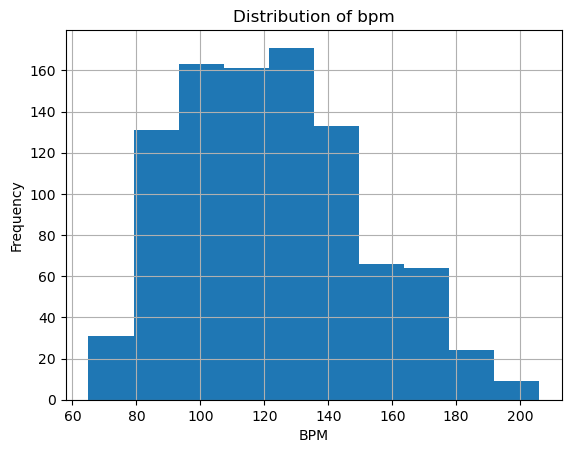

In [14]:
plt.figure()
df['bpm'].hist()
plt.title("Distribution of bpm")
plt.xlabel("BPM")
plt.ylabel("Frequency")
plt.show()

The distribution of bpm shows that most songs fall within range of approximatley 90 to 140 bpm. The highest concentration appears around 110 to 130 bpm. This indicates that this is a common tempo range for popular music. There are fewer songs at very low and very high bpm values, which suggests that extreme tempos are less common among popular tracks.

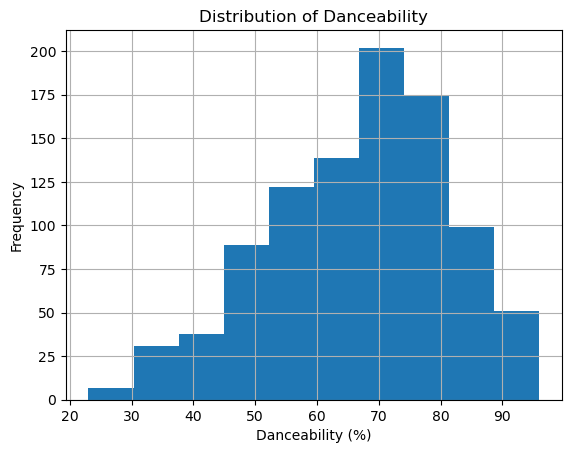

In [15]:
plt.figure()
df['danceability_%'].hist()
plt.title("Distribution of Danceability")
plt.xlabel("Danceability (%)")
plt.ylabel("Frequency")
plt.show()

The distribution of danceability shows that most songs fall within the range of approximately 60% to 80%. The highest concentration appears around 65% to 75%, which indicates that popular songs tend to have moderately high danceability. There are fewer songs with very low or extremely high danceability, suggesting that most popular tracks are designed to be rhythmically engaging but not overly extreme.

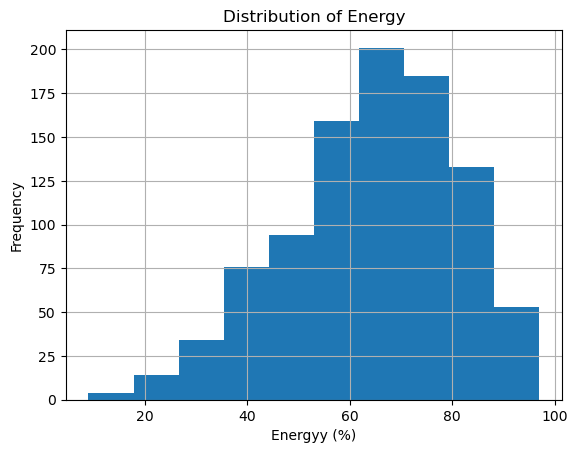

In [16]:
plt.figure()
df['energy_%'].hist()
plt.title("Distribution of Energy")
plt.xlabel("Energyy (%)")
plt.ylabel("Frequency")
plt.show()

The distribution of energy shows that most songs fall within the range of approximately 50% to 80%. The highest concentration appears around 60% to 75%, which indicates that popular songs tend to have moderately high energy levels. There are fewer songs with very low energy, suggesting that most popular tracks are designed to be lively and engaging rather than calm or slow.

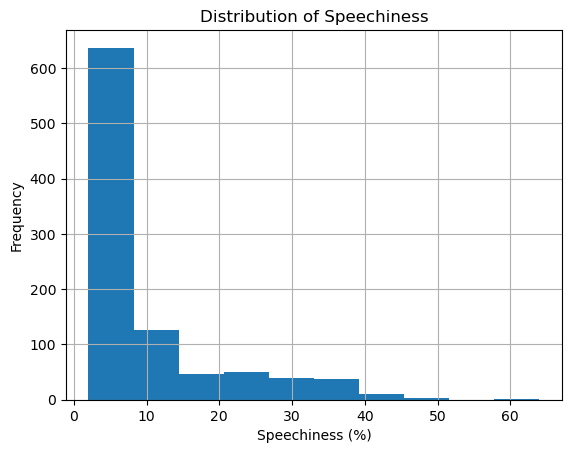

In [17]:
plt.figure()
df['speechiness_%'].hist()
plt.title("Distribution of Speechiness")
plt.xlabel("Speechiness (%)")
plt.ylabel("Frequency")
plt.show()

The distribution of speechiness shows that most songs have very low speechiness values, typically between 0% and 10%. This indicates that the majority of popular songs contain very little spoken word content and are primarily musical. There are a few songs with higher speechiness values, but they are much less common, suggesting that songs with heavy spoken elements are not as prevalent among popular tracks.

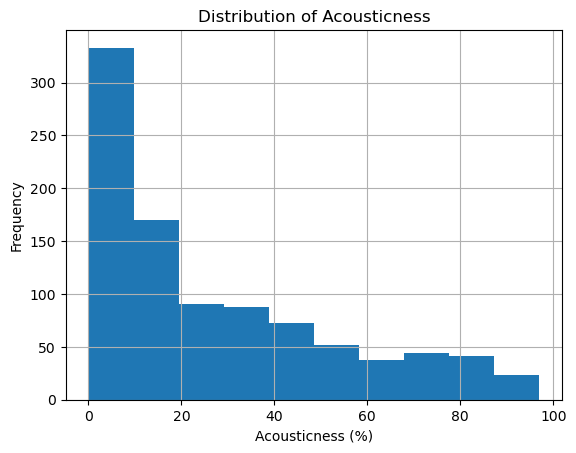

In [18]:
plt.figure()
df['acousticness_%'].hist()
plt.title("Distribution of Acousticness")
plt.xlabel("Acousticness (%)")
plt.ylabel("Frequency")
plt.show()

The distribution of acousticness shows that most songs have low acousticness values, typically between 0% and 20%. This indicates that the majority of popular songs are less acoustic and more electronically produced. There are fewer songs with higher acousticness values, but they are still present across the full range, suggesting that acoustic elements are used less frequently but still appear in some popular tracks.

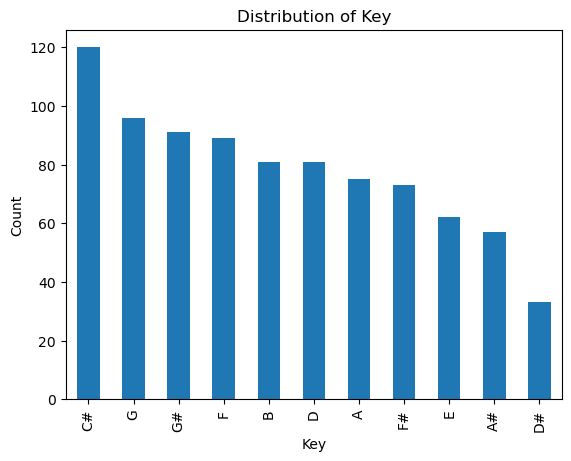

In [19]:
plt.figure()
df['key'].value_counts().plot(kind='bar')
plt.title("Distribution of Key")
plt.xlabel("Key")
plt.ylabel("Count")
plt.show()

The distribution of musical keys shows that some keys are more common than others in popular songs. The key of C# appears most frequently, followed by several other keys such as G and G#. This suggests that certain keys are preferred in music production, likely because they work well with vocal ranges and overall sound. Some keys, like D#, appear much less frequently, indicating they are less commonly used in popular tracks.

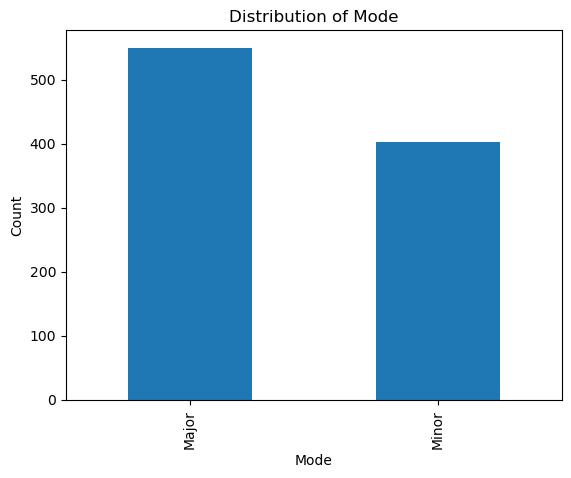

In [20]:
plt.figure()
df['mode'].value_counts().plot(kind='bar')
plt.title("Distribution of Mode")
plt.xlabel("Mode")
plt.ylabel("Count")
plt.show()

The distribution of mode shows that most songs are in the major mode, with a higher count compared to minor. This suggests that popular songs tend to favor a brighter and more uplifting sound, which is commonly associated with major keys. While minor mode songs are still present, they appear less frequently, indicating they are less dominant in popular music.

Based on the visualizations, a guaranteed smash hit song would have a BPM between approximately 110 and 130, as most songs fall within this range. The key should ideally be C#, since it appears most frequently in the dataset. The mode should be major, as it is more common than minor and is associated with a brighter sound.

For danceability, the ideal range would be between 65% and 80%, indicating a moderately high level suitable for popular music. Energy should be between 60% and 80%, suggesting that popular songs are typically lively but not overwhelming.

Speechiness should be low, generally between 0% and 10%, since most popular songs contain minimal spoken content. Acousticness should also be relatively low, around 0% to 20%, indicating that most popular songs are more electronically produced rather than acoustic.

In [21]:
filtered = df[
    (df['bpm'] >= 110) & (df['bpm'] <= 130) &
    (df['danceability_%'] >= 65) & (df['danceability_%'] <= 80) &
    (df['energy_%'] >= 60) & (df['energy_%'] <= 80) &
    (df['speechiness_%'] <= 10) &
    (df['acousticness_%'] <= 20) &
    (df['mode'] == 'Major') &
    (df['key'] == 'C#')
]

filtered[['track_name', 'artist(s)_name', 'bpm']]

,track_name,artist(s)_name,bpm
106,Cold Heart - PNAU Remix,"Dua Lipa, Elton John, Pnau",116
168,We Found Love,"Rihanna, Calvin Harris",128
236,AMERICA HAS A PROBLEM (feat. Kendrick Lamar),"Kendrick Lamar, Beyoncï¿",126


Using the criteria identified for a guaranteed smash hit, several songs in the dataset match all of the conditions. These include "Cold Heart - PNAU Remix" by Dua Lipa and Elton John, "We Found Love" by Rihanna and Calvin Harris, and "AMERICA HAS A PROBLEM" by Kendrick Lamar and Beyoncé. These songs are all well-known and popular, which suggests that the selected feature ranges are accurate in identifying characteristics of successful music. This supports the idea that factors such as BPM, danceability, energy, and key play an important role in determining a song's popularity.

A well-known smash hit is "We Found Love" by Rihanna. This song falls within the BPM range identified, with a tempo of 128 BPM. It also matches the selected characteristics, including high danceability, high energy, and major mode. Compared to other songs in the dataset, "We Found Love" aligns closely with the typical values observed in the visualizations. This supports the idea that songs with these features are more likely to become popular and widely recognized.